In [18]:
import arcpy
from arcpy import env
import os
import numpy as np
from arcgis import GIS
from arcgis.features import GeoAccessor
from arcgis.features import GeoSeriesAccessor
import pandas as pd
import matplotlib.pyplot as plt

arcpy.env.overwriteOutput = True
arcpy.env.parallelProcessingFactor = "90%"

# show all columns
pd.options.display.max_columns = None

# pd.pivot_table(df, values='a', index='b', columns='c', aggfunc='sum', fill_value=0)
# pd.DataFrame.spatial.from_featureclass(???)  
# df.spatial.to_featureclass(location=???,sanitize_columns=False)  

# gsa = arcgis.features.GeoSeriesAccessor(df['SHAPE'])  
# df['AREA'] = gsa.area  # KNOW YOUR UNITS

In [19]:
## spatial join
# target_features = ?
# join_features = ?
# output_features = os.path.join(gdb, ?)

# fieldmappings = arcpy.FieldMappings()
# fieldmappings.addTable(target_features)
# fieldmappings.addTable(join_features)

# # variable
# fieldindex = fieldmappings.findFieldMapIndex(?)
# fieldmap = fieldmappings.getFieldMap(fieldindex)
# fieldmap.mergeRule = 'Sum'
# fieldmappings.replaceFieldMap(fieldindex, fieldmap)

# sj = arcpy.SpatialJoin_analysis(target_features, join_features, output_features,'JOIN_ONE_TO_ONE', "KEEP_ALL", fieldmappings, match_option="INTERSECT")
# sj_df = pd.DataFrame.spatial.from_featureclass(sj[0]).copy()

In [20]:
# fill NA values in Spatially enabled dataframes (ignores SHAPE column)
def fill_na_sedf(df_with_shape_column, fill_value=0):
    if 'SHAPE' in list(df_with_shape_column.columns):
        cols_to_fill = df_with_shape_column.columns.difference(['SHAPE'])
        df_with_shape_column[cols_to_fill] = df_with_shape_column[cols_to_fill].fillna(fill_value)
        return df_with_shape_column
    else:
        raise Exception("Dataframe does not include 'SHAPE' column")

In [21]:
outputs = ['.\\Outputs', "scratch.gdb", 'results.gdb']

if not os.path.exists(outputs[0]):
    os.makedirs(outputs[0])

gdb = os.path.join(outputs[0], outputs[1])
gdb2 = os.path.join(outputs[0], outputs[2])

if not arcpy.Exists(gdb):
    arcpy.CreateFileGDB_management(outputs[0], outputs[1])

if not arcpy.Exists(gdb2):
    arcpy.CreateFileGDB_management(outputs[0], outputs[2])

In [22]:
# se_dec = pd.read_csv(r"E:\Tasks\REMM-Manage-Base-Year-Data-2023\Inputs\Tables\SE_2023_6Runs_TAZ900_20251217.csv")
# se_jan= pd.read_csv(r"E:\Tasks\REMM-Manage-Base-Year-Data-2023\Inputs\Tables\SE_2023_6Runs_TAZ900_20260202.csv")
se_dec = pd.read_csv(r"E:\Tasks\REMM-Manage-Base-Year-Data-2023\Inputs\Tables\SE_2023_lock2.csv")
se_jan= pd.read_csv(r"E:\Tasks\REMM-Manage-Base-Year-Data-2023\Inputs\Tables\SE_2023_lock1.csv")

In [23]:
vars = ['TOTHH', 'HHPOP', 'HHSIZE', 'TOTEMP', 'RETEMP',
       'INDEMP', 'OTHEMP', 'ALLEMP', 'RETL', 'FOOD', 'MANU', 'WSLE', 'OFFI',
       'GVED', 'HLTH', 'OTHR', 'FM_AGRI', 'FM_MING', 'FM_CONS', 'HBJ',
       'AVGINCOME', 'Enrol_Elem', 'Enrol_Midl', 'Enrol_High']

names_old = [f + '_OLD' for f in vars]
names_new = [f + '_NEW' for f in vars]

columns_old = dict(zip(vars, names_old))
columns_new = dict(zip(vars, names_new))

se_dec.rename(columns_old, axis=1, inplace=True)
se_jan.rename(columns_new, axis=1, inplace=True)

se_dec = se_dec.drop(['CO_TAZID','CO_FIPS', 'CO_NAME'], axis=1)
se_jan = se_jan.drop(['CO_TAZID','CO_FIPS', 'CO_NAME'], axis=1)

print(se_dec.columns)
print(se_jan.columns)

Index([';TAZID', 'TOTHH_OLD', 'HHPOP_OLD', 'HHSIZE_OLD', 'TOTEMP_OLD',
       'RETEMP_OLD', 'INDEMP_OLD', 'OTHEMP_OLD', 'ALLEMP_OLD', 'RETL_OLD',
       'FOOD_OLD', 'MANU_OLD', 'WSLE_OLD', 'OFFI_OLD', 'GVED_OLD', 'HLTH_OLD',
       'OTHR_OLD', 'FM_AGRI_OLD', 'FM_MING_OLD', 'FM_CONS_OLD', 'HBJ_OLD',
       'AVGINCOME_OLD', 'Enrol_Elem_OLD', 'Enrol_Midl_OLD', 'Enrol_High_OLD'],
      dtype='object')
Index([';TAZID', 'TOTHH_NEW', 'HHPOP_NEW', 'HHSIZE_NEW', 'TOTEMP_NEW',
       'RETEMP_NEW', 'INDEMP_NEW', 'OTHEMP_NEW', 'ALLEMP_NEW', 'RETL_NEW',
       'FOOD_NEW', 'MANU_NEW', 'WSLE_NEW', 'OFFI_NEW', 'GVED_NEW', 'HLTH_NEW',
       'OTHR_NEW', 'FM_AGRI_NEW', 'FM_MING_NEW', 'FM_CONS_NEW', 'HBJ_NEW',
       'AVGINCOME_NEW', 'Enrol_Elem_NEW', 'Enrol_Midl_NEW', 'Enrol_High_NEW'],
      dtype='object')


In [24]:
merged = se_dec.merge(se_jan, on=';TAZID', how='left')

c:\Users\jreynolds\AppData\Local\ESRI\conda\envs\arcgispro-py3-clone\Lib\site-packages\pandas\plotting\_matplotlib\core.py:509: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


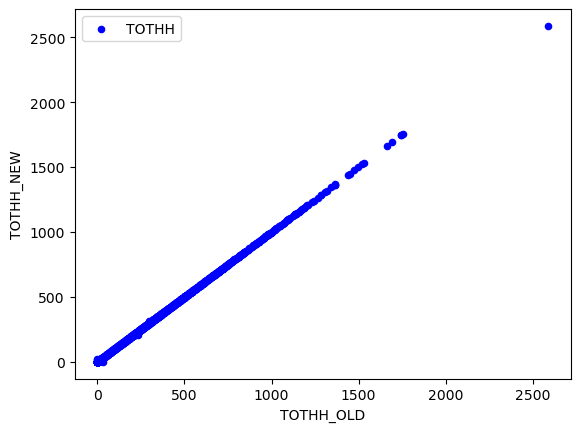

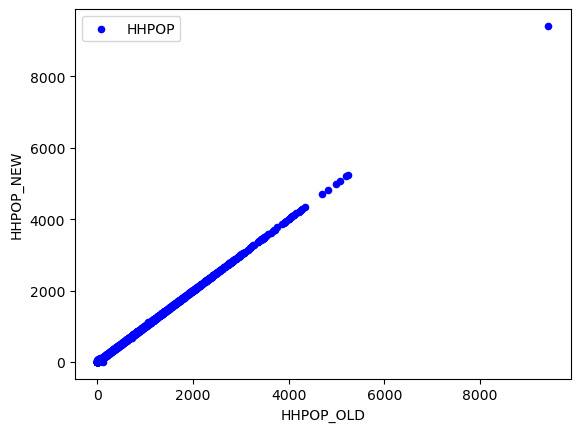

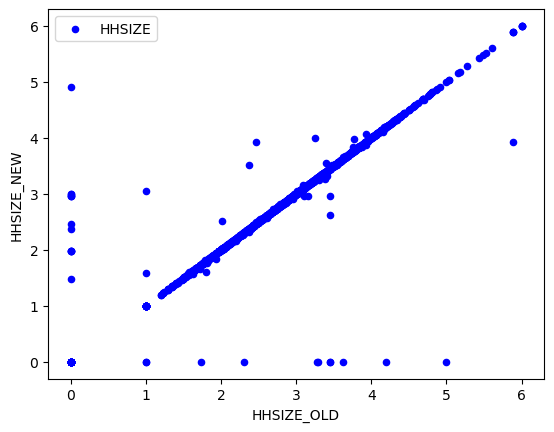

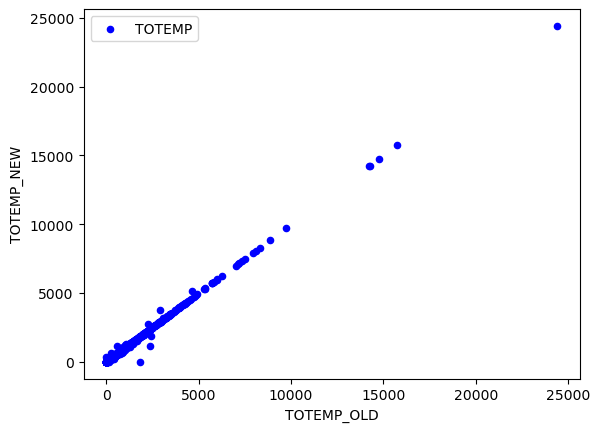

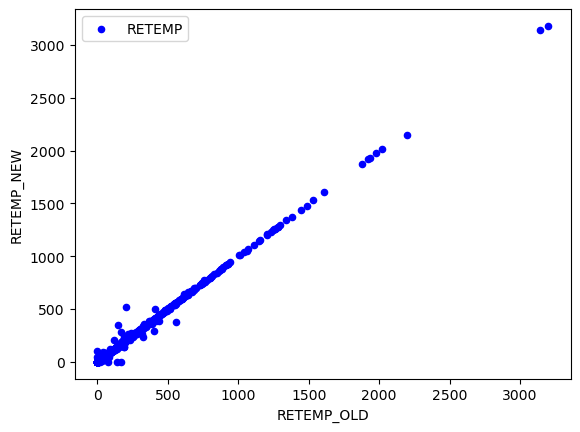

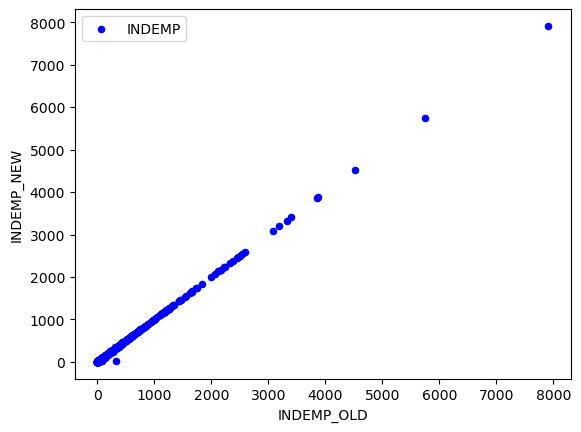

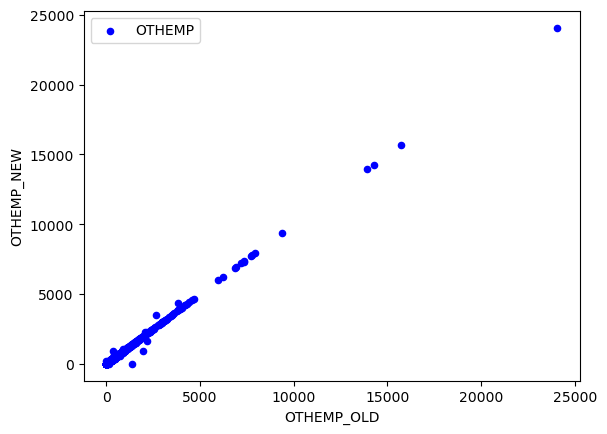

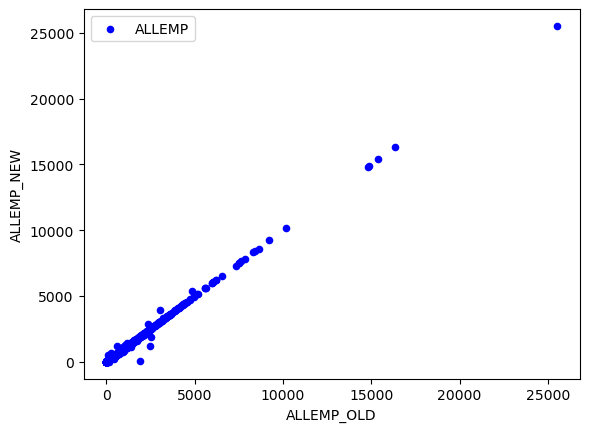

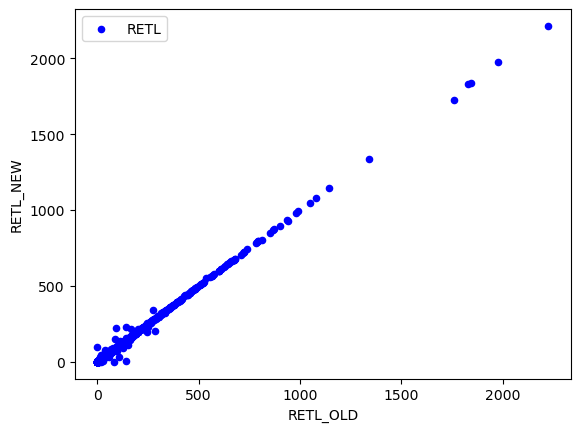

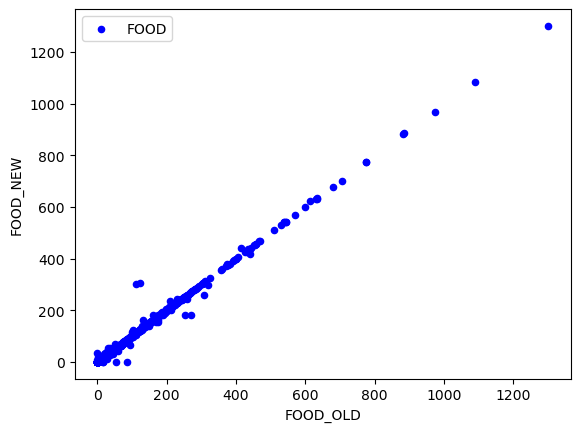

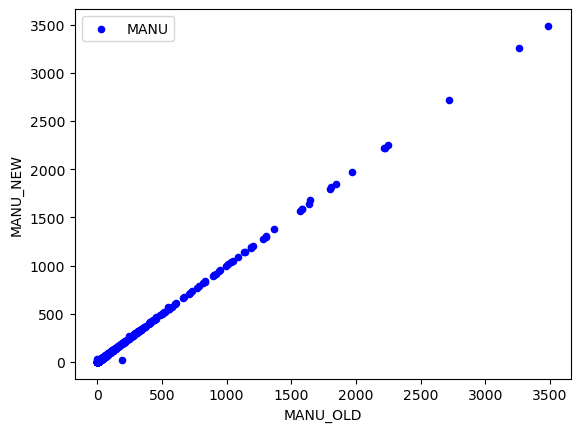

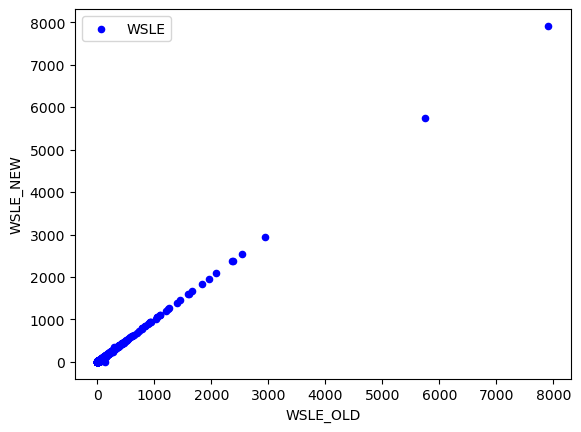

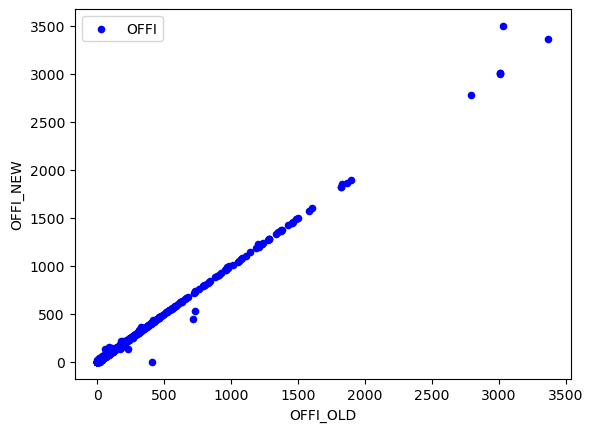

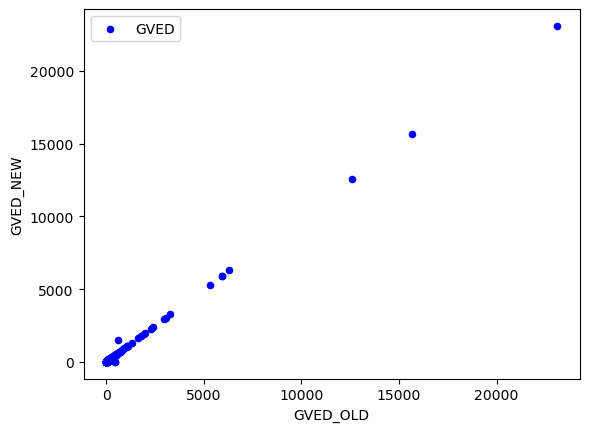

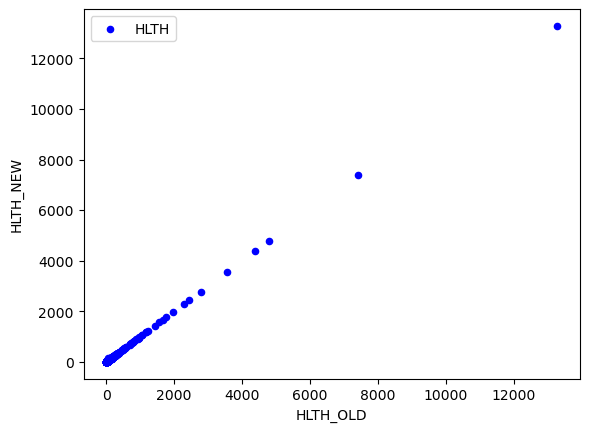

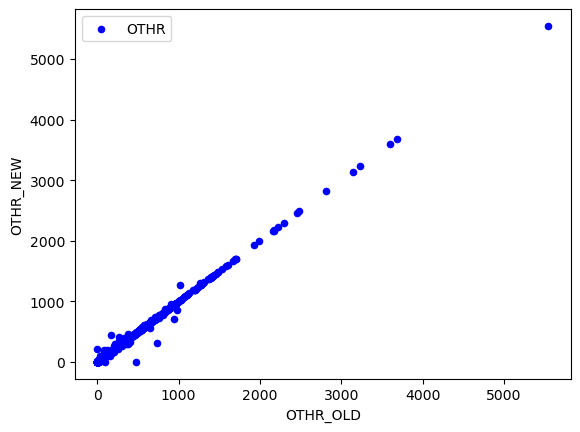

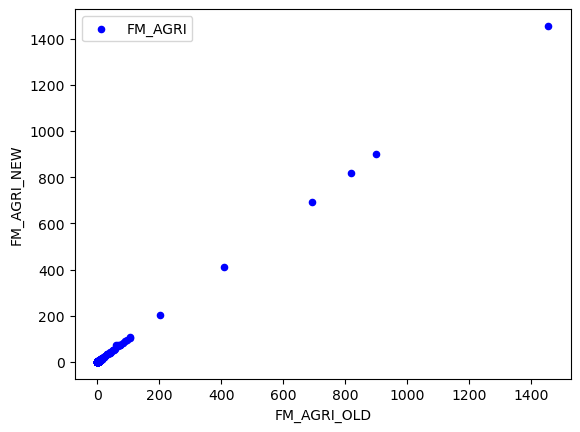

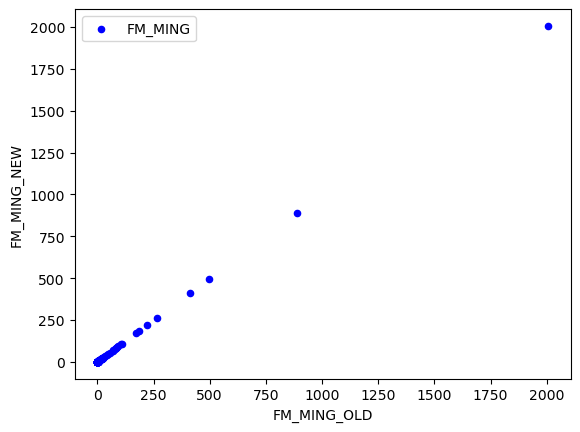

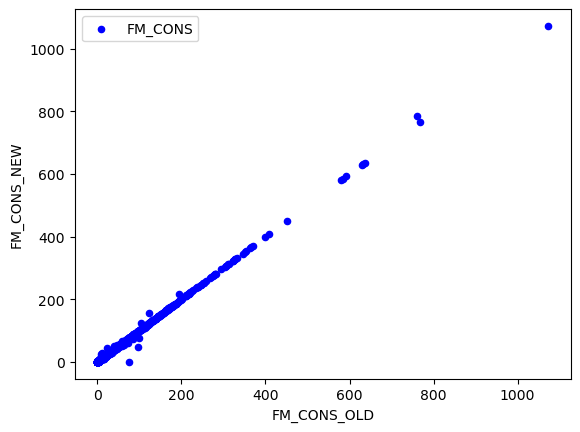

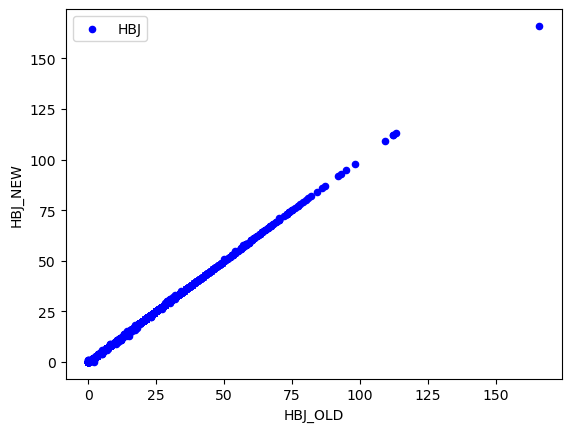

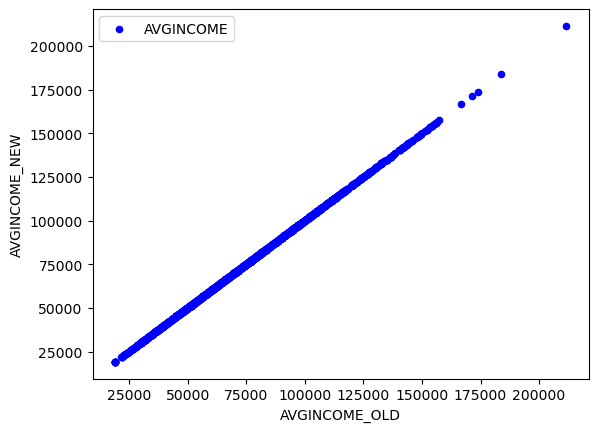

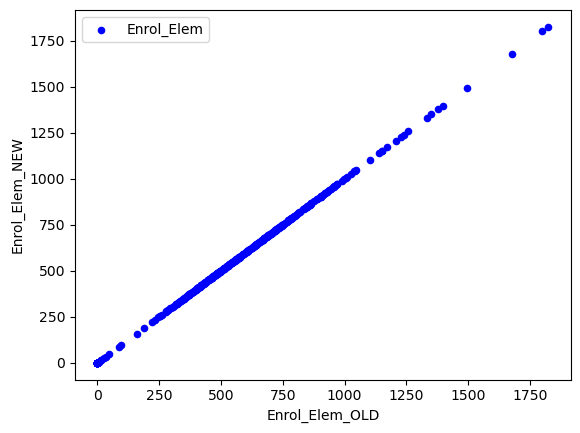

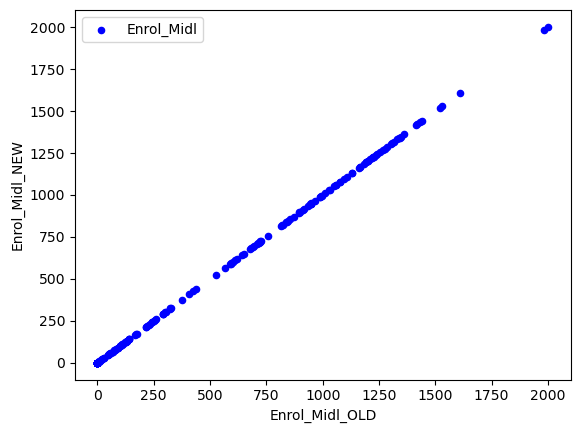

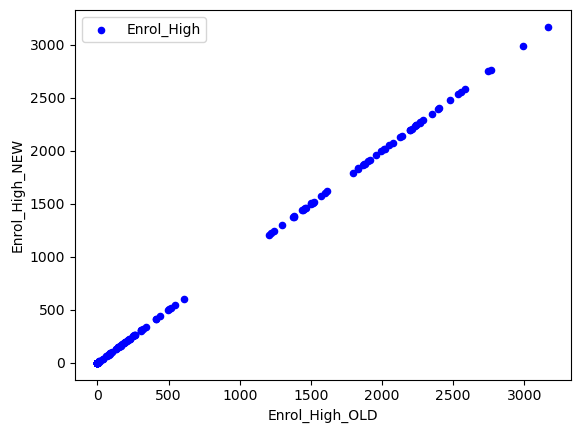

In [25]:
# Plot first DataFrame
for var in vars:
    ax = merged.plot.scatter(x= f'{var}_OLD', y=f'{var}_NEW', color='blue', label=var)